# Wound Healing Random-Walker Simulation

This notebook builds an irregular 2D wound boundary, fills it, finds its center with K-means, selects distributed boundary seed points, runs biased random walkers inside the wound, and exports the healing process as a GIF.

In [225]:
%pip install -q numpy matplotlib scikit-learn pillow

Note: you may need to restart the kernel to use updated packages.


In [226]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
from collections import deque

rng = np.random.default_rng(41)

grid_size = 150
num_boundary_samples = 150
n_start_points = 150
num_steps = 200
walker_noise = 0.65
heal_threshold = 3
snapshot_every = 3
output_gif = "wound_healing_process.gif"

In [227]:
# ── Step 1: Generate noisy boundary points ──────────────────────────────────
def generate_noisy_boundary_points(center_xy, base_radius, n_points, noise_sigma=100.0, harmonic_strength=1.18):
    angles = np.linspace(0, 2 * np.pi, n_points, endpoint=True)
    harmonic = 1 + harmonic_strength * np.sin(3 * angles) + 0.12 * np.sin(7 * angles + 1.3)
    radial_noise = rng.normal(0.0, noise_sigma, size=n_points)
    radius = np.clip(base_radius * harmonic + radial_noise, base_radius * 0.45, base_radius * 1.45)

    x = center_xy[0] + radius * np.cos(angles)
    y = center_xy[1] + radius * np.sin(angles)
    points = np.column_stack([x, y])
    points = np.clip(points, 2, grid_size - 3)
    return points


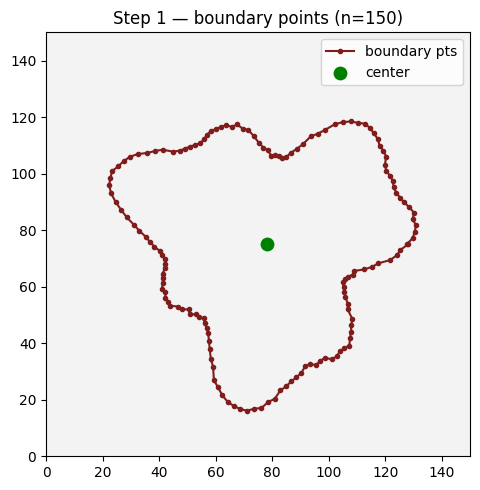

x range: [22.3, 130.9]
y range: [16.1, 118.5]


In [228]:
# ── Step 1: Generate boundary points ────────────────────────────────────────
true_center_xy = np.array([grid_size * 0.52, grid_size * 0.50])
boundary_points_xy = generate_noisy_boundary_points(
    true_center_xy, base_radius=grid_size*0.3, n_points=num_boundary_samples,
    noise_sigma=0.5, harmonic_strength=0.22
)

fig_d1, ax_d1 = plt.subplots(figsize=(5, 5))
ax_d1.set_facecolor("#f3f3f3")
ax_d1.plot(boundary_points_xy[:, 0], boundary_points_xy[:, 1], "o-",
           color="#7f1d1d", ms=3, lw=1.5, label="boundary pts")
ax_d1.scatter(*true_center_xy, c="green", s=80, zorder=5, label="center")
ax_d1.set_xlim(0, grid_size); ax_d1.set_ylim(0, grid_size)
ax_d1.set_aspect("equal")
ax_d1.set_title(f"Step 1 — boundary points (n={len(boundary_points_xy)})")
ax_d1.legend()
plt.tight_layout(); plt.show()
print(f"x range: [{boundary_points_xy[:, 0].min():.1f}, {boundary_points_xy[:, 0].max():.1f}]")
print(f"y range: [{boundary_points_xy[:, 1].min():.1f}, {boundary_points_xy[:, 1].max():.1f}]")


In [229]:
# ── Step 2: Rasterise polygon → binary wound mask ───────────────────────────
def polygon_to_mask(boundary_points_xy, size):
    yy, xx = np.mgrid[0:size, 0:size]
    all_pixels_xy = np.column_stack([xx.ravel(), yy.ravel()])
    path = Path(boundary_points_xy)
    mask = path.contains_points(all_pixels_xy).reshape(size, size)
    return mask


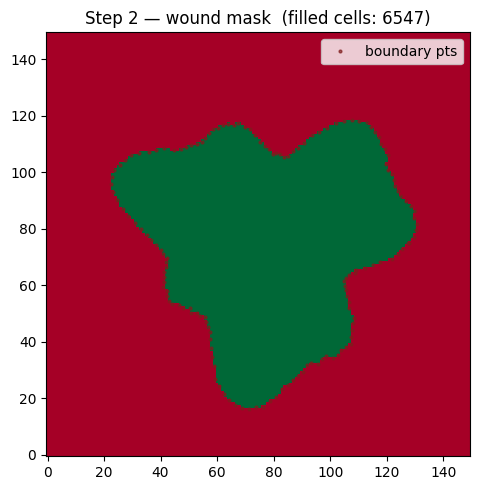

Mask shape    : (150, 150)
Filled cells  : 6547
Boundary pts inside mask: 80 / 150


In [230]:
# ── Step 2: Rasterise → wound mask ──────────────────────────────────────────
wound_mask = polygon_to_mask(boundary_points_xy, grid_size)

fig_d2, ax_d2 = plt.subplots(figsize=(5, 5))
ax_d2.imshow(wound_mask, origin="lower", cmap="RdYlGn", interpolation="nearest")
ax_d2.plot(boundary_points_xy[:, 0], boundary_points_xy[:, 1],
           "o", ms=2, color="#7f1d1d", alpha=0.7, label="boundary pts")
ax_d2.set_title(f"Step 2 — wound mask  (filled cells: {wound_mask.sum()})")
ax_d2.set_aspect("equal"); ax_d2.legend()
plt.tight_layout(); plt.show()

print(f"Mask shape    : {wound_mask.shape}")
print(f"Filled cells  : {wound_mask.sum()}")
print(f"Boundary pts inside mask: "
      f"{sum(wound_mask[int(p[1]), int(p[0])] for p in boundary_points_xy)} / {len(boundary_points_xy)}")


In [231]:
# ── Step 3: Extract 1-pixel-wide boundary ring ──────────────────────────────
def extract_boundary_mask(mask):
    interior = np.zeros_like(mask, dtype=bool)
    interior[1:-1, 1:-1] = (
        mask[1:-1, 1:-1]
        & mask[:-2, 1:-1]
        & mask[2:, 1:-1]
        & mask[1:-1, :-2]
        & mask[1:-1, 2:]
    )
    return mask & ~interior


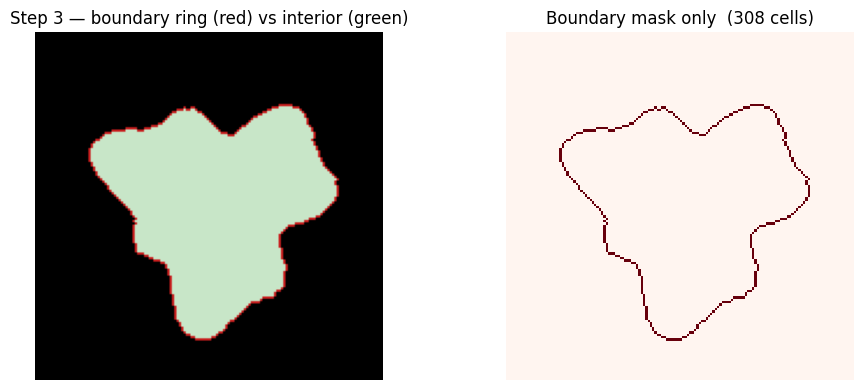

Interior cells : 6239
Boundary cells : 308


In [232]:
# ── Step 3: Extract boundary ring ───────────────────────────────────────────
boundary_mask = extract_boundary_mask(wound_mask)
boundary_cells_rc = np.argwhere(boundary_mask)

overlay = np.zeros((*wound_mask.shape, 3), dtype=np.uint8)
overlay[wound_mask] = [200, 230, 200]
overlay[boundary_mask] = [200, 30, 30]

fig_d3, axes_d3 = plt.subplots(1, 2, figsize=(10, 4))
axes_d3[0].imshow(overlay, origin="lower")
axes_d3[0].set_title("Step 3 — boundary ring (red) vs interior (green)")
axes_d3[0].axis("off")

axes_d3[1].imshow(boundary_mask, origin="lower", cmap="Reds", interpolation="nearest")
axes_d3[1].set_title(f"Boundary mask only  ({boundary_cells_rc.shape[0]} cells)")
axes_d3[1].axis("off")

plt.tight_layout(); plt.show()
print(f"Interior cells : {wound_mask.sum() - boundary_mask.sum()}")
print(f"Boundary cells : {boundary_mask.sum()}")


In [233]:
# ── Step 4: BFS distance-to-boundary map ────────────────────────────────────
def bfs_distance_to_boundary(mask, boundary_mask):
    dist = np.full(mask.shape, np.inf, dtype=float)
    q = deque()

    boundary_cells = np.argwhere(boundary_mask)
    for r, c in boundary_cells:
        dist[r, c] = 0.0
        q.append((r, c))

    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    while q:
        r, c = q.popleft()
        for dr, dc in neighbors:
            nr, nc = r + dr, c + dc
            if nr < 0 or nr >= mask.shape[0] or nc < 0 or nc >= mask.shape[1]:
                continue
            if not mask[nr, nc]:
                continue
            if dist[nr, nc] > dist[r, c] + 1:
                dist[nr, nc] = dist[r, c] + 1
                q.append((nr, nc))

    return dist


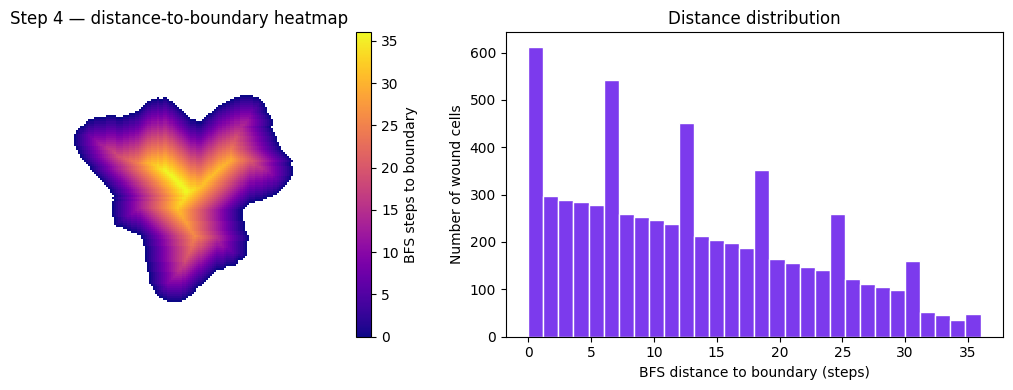

Max distance from boundary : 36 steps
Mean distance              : 12.8 steps


In [234]:
# ── Step 4: BFS distance-to-boundary map ────────────────────────────────────
dist_to_boundary = bfs_distance_to_boundary(wound_mask, boundary_mask)

dist_plot = dist_to_boundary.copy()
dist_plot[~wound_mask] = np.nan

fig_d4, axes_d4 = plt.subplots(1, 2, figsize=(11, 4))

im = axes_d4[0].imshow(dist_plot, origin="lower", cmap="plasma", interpolation="nearest")
plt.colorbar(im, ax=axes_d4[0], label="BFS steps to boundary")
axes_d4[0].set_title("Step 4 — distance-to-boundary heatmap")
axes_d4[0].axis("off")

finite_vals = dist_to_boundary[np.isfinite(dist_to_boundary)]
axes_d4[1].hist(finite_vals, bins=30, color="#7c3aed", edgecolor="white")
axes_d4[1].set_xlabel("BFS distance to boundary (steps)")
axes_d4[1].set_ylabel("Number of wound cells")
axes_d4[1].set_title("Distance distribution")

plt.tight_layout(); plt.show()
print(f"Max distance from boundary : {finite_vals.max():.0f} steps")
print(f"Mean distance              : {finite_vals.mean():.1f} steps")


In [235]:
# ── Step 5: Pick spatially distributed start points on the boundary ─────────
def pick_distributed_start_points(boundary_cells_rc, center_rc, n_points, center_weight=0.5, spread_weight=0.7):
    if len(boundary_cells_rc) == 0:
        raise ValueError("No boundary cells available to pick start points.")

    n_points = min(n_points, len(boundary_cells_rc))
    d_center = np.linalg.norm(boundary_cells_rc - center_rc, axis=1)

    selected_indices = [int(np.argmax(d_center))]

    while len(selected_indices) < n_points:
        rem = np.setdiff1d(np.arange(len(boundary_cells_rc)), np.array(selected_indices), assume_unique=False)
        rem_cells = boundary_cells_rc[rem]

        spread = np.min(
            np.linalg.norm(rem_cells[:, None, :] - boundary_cells_rc[selected_indices][None, :, :], axis=2),
            axis=1
        )

        center_term = d_center[rem] / (d_center[rem].max() + 1e-9)
        spread_term = spread / (spread.max() + 1e-9)
        score = center_weight * center_term + spread_weight * spread_term

        selected_indices.append(int(rem[np.argmax(score)]))

    return boundary_cells_rc[selected_indices]


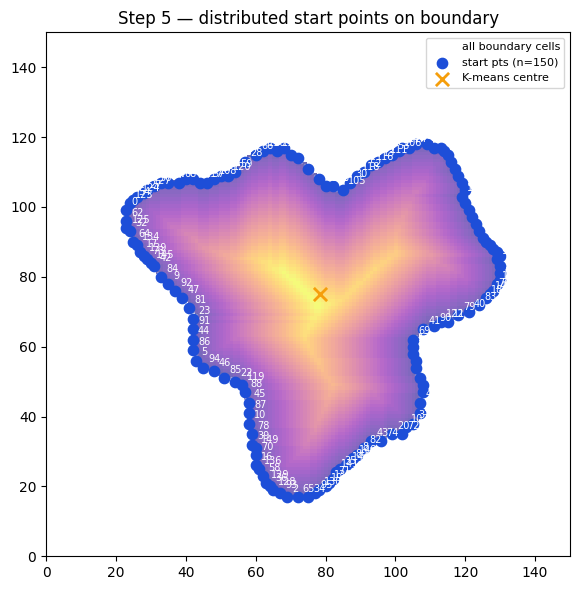

Min pairwise distance between start pts : 1.4 px
Mean pairwise distance                  : 60.5 px

Wound area  : 6547 cells
Boundary    : 308 cells
Walkers     : 150
Centre (x,y): [78.34 75.03]


In [236]:
# ── Step 5: Find centre (K-means) + distributed start points ────────────────
kmeans = KMeans(n_clusters=1, n_init=12, random_state=42)
kmeans.fit(boundary_points_xy)
middle_xy = kmeans.cluster_centers_[0]
middle_rc = np.array([middle_xy[1], middle_xy[0]])

start_cells_rc = pick_distributed_start_points(boundary_cells_rc, middle_rc, n_start_points)

fig_d5, ax_d5 = plt.subplots(figsize=(6, 6))
ax_d5.imshow(dist_plot, origin="lower", cmap="plasma", interpolation="nearest", alpha=0.6)
ax_d5.scatter(boundary_cells_rc[:, 1], boundary_cells_rc[:, 0],
              c="white", s=2, alpha=0.3, label="all boundary cells")
ax_d5.scatter(start_cells_rc[:, 1], start_cells_rc[:, 0],
              c="#1d4ed8", s=55, zorder=5, label=f"start pts (n={len(start_cells_rc)})")
ax_d5.scatter(middle_xy[0], middle_xy[1],
              c="#f59e0b", s=90, marker="x", linewidths=2, zorder=6, label="K-means centre")

for idx, (r, c) in enumerate(start_cells_rc):
    ax_d5.text(c + 1.5, r + 1.5, str(idx), color="white", fontsize=7, zorder=7)

ax_d5.set_title("Step 5 — distributed start points on boundary")
ax_d5.set_xlim(0, grid_size); ax_d5.set_ylim(0, grid_size)
ax_d5.set_aspect("equal"); ax_d5.legend(fontsize=8)
plt.tight_layout(); plt.show()

from itertools import combinations
if len(start_cells_rc) > 1:
    pw_dists = [np.linalg.norm(start_cells_rc[i] - start_cells_rc[j])
                for i, j in combinations(range(len(start_cells_rc)), 2)]
    print(f"Min pairwise distance between start pts : {min(pw_dists):.1f} px")
    print(f"Mean pairwise distance                  : {np.mean(pw_dists):.1f} px")
print(f"\nWound area  : {wound_mask.sum()} cells")
print(f"Boundary    : {len(boundary_cells_rc)} cells")
print(f"Walkers     : {len(start_cells_rc)}")
print(f"Centre (x,y): {middle_xy.round(2)}")


In [237]:
def run_walker_healing(mask, start_cells_rc, middle_rc, dist_to_boundary, n_steps, noise_sigma, heal_threshold, snapshot_every):
    walkers = start_cells_rc.copy().astype(int)
    visit_counts = np.zeros(mask.shape, dtype=np.int32)
    healed = np.zeros(mask.shape, dtype=bool)

    snapshots = []
    offsets = np.array([
        [-1, -1], [-1, 0], [-1, 1],
        [0, -1],  [0, 0],  [0, 1],
        [1, -1],  [1, 0],  [1, 1],
    ], dtype=int)

    max_center_dist = np.linalg.norm(np.array(mask.shape) - middle_rc)

    for step in range(n_steps):
        for i in range(len(walkers)):
            pos = walkers[i].astype(float)
            r, c = int(pos[0]), int(pos[1])

            if not (0 <= r < mask.shape[0] and 0 <= c < mask.shape[1] and mask[r, c]):
                walkers[i] = start_cells_rc[i % len(start_cells_rc)]
                r, c = walkers[i]
                pos = walkers[i].astype(float)

            center_vec = middle_rc - pos
            center_norm = np.linalg.norm(center_vec) + 1e-9
            center_dir = center_vec / center_norm

            d_center = min(center_norm, max_center_dist)
            d_center_norm = d_center / (max_center_dist + 1e-9)

            d_edge = dist_to_boundary[r, c]
            d_edge_norm = d_edge / (np.nanmax(dist_to_boundary[np.isfinite(dist_to_boundary)]) + 1e-9)

            # Near edge -> move inward. Near middle -> move outward.
            p_to_center = d_center_norm / (d_center_norm + d_edge_norm + 1e-9)
            drift_vec = p_to_center * center_dir + (1 - p_to_center) * (-center_dir)
            drift_vec += rng.normal(0.0, noise_sigma, size=2)

            candidates = walkers[i][None, :] + offsets
            valid = (
                (candidates[:, 0] >= 0) & (candidates[:, 0] < mask.shape[0])
                & (candidates[:, 1] >= 0) & (candidates[:, 1] < mask.shape[1])
            )
            candidates = candidates[valid]
            in_wound = mask[candidates[:, 0], candidates[:, 1]]
            candidates = candidates[in_wound]

            if len(candidates) == 0:
                continue

            step_vecs = candidates - pos
            directional_score = step_vecs @ drift_vec
            explore_score = 1.0 / (1.0 + visit_counts[candidates[:, 0], candidates[:, 1]])
            jitter = rng.normal(0.0, 0.03, size=len(candidates))

            score = directional_score + 0.35 * explore_score + jitter
            best_idx = int(np.argmax(score))
            walkers[i] = candidates[best_idx]

            rr, cc = walkers[i]
            visit_counts[rr, cc] += 1
            if visit_counts[rr, cc] >= heal_threshold:
                healed[rr, cc] = True

        if (step % snapshot_every == 0) or (step == n_steps - 1):
            snapshots.append((step, visit_counts.copy(), healed.copy(), walkers.copy()))

    return snapshots, visit_counts, healed


snapshots, visit_counts, healed = run_walker_healing(
    mask=wound_mask,
    start_cells_rc=start_cells_rc,
    middle_rc=middle_rc,
    dist_to_boundary=dist_to_boundary,
    n_steps=num_steps,
    noise_sigma=walker_noise,
    heal_threshold=heal_threshold,
    snapshot_every=snapshot_every,
)

print(f"Saved snapshots: {len(snapshots)}")
print(f"Healed cells: {healed.sum()} / {wound_mask.sum()} ({100 * healed.sum() / wound_mask.sum():.1f}%)")

Saved snapshots: 68
Healed cells: 2873 / 6547 (43.9%)


In [238]:
fig, ax = plt.subplots(figsize=(7, 7))
cmap = ListedColormap(["#ececec", "#991b1b", "#22c55e"])

def make_state(mask, healed):
    state = np.zeros(mask.shape, dtype=np.uint8)
    state[mask] = 1
    state[healed] = 2
    return state

init_state = make_state(wound_mask, snapshots[0][2])
img = ax.imshow(init_state, cmap=cmap, vmin=0, vmax=2, origin="lower", animated=True)
walker_scatter = ax.scatter(snapshots[0][3][:, 1], snapshots[0][3][:, 0], c="#60a5fa", s=16, alpha=0.9, animated=True)
center_marker = ax.scatter([middle_xy[0]], [middle_xy[1]], c="#f59e0b", marker="x", s=90, linewidths=2)
ax.set_title("Wound Healing Process (Random Walkers)")
ax.set_xlim(0, grid_size - 1)
ax.set_ylim(0, grid_size - 1)
ax.set_aspect("equal")
ax.axis("off")

def update(frame_idx):
    step, _, healed_frame, walkers_frame = snapshots[frame_idx]
    img.set_data(make_state(wound_mask, healed_frame))
    walker_scatter.set_offsets(np.column_stack([walkers_frame[:, 1], walkers_frame[:, 0]]))
    healed_pct = 100 * healed_frame.sum() / wound_mask.sum()
    ax.set_title(f"Wound Healing Process | Step {step} | Healed {healed_pct:.1f}%")
    return img, walker_scatter, center_marker

anim = FuncAnimation(fig, update, frames=len(snapshots), interval=70, blit=True)
anim.save(output_gif, writer=PillowWriter(fps=14))
plt.close(fig)

print(f"GIF saved to: {output_gif}")

GIF saved to: wound_healing_process.gif


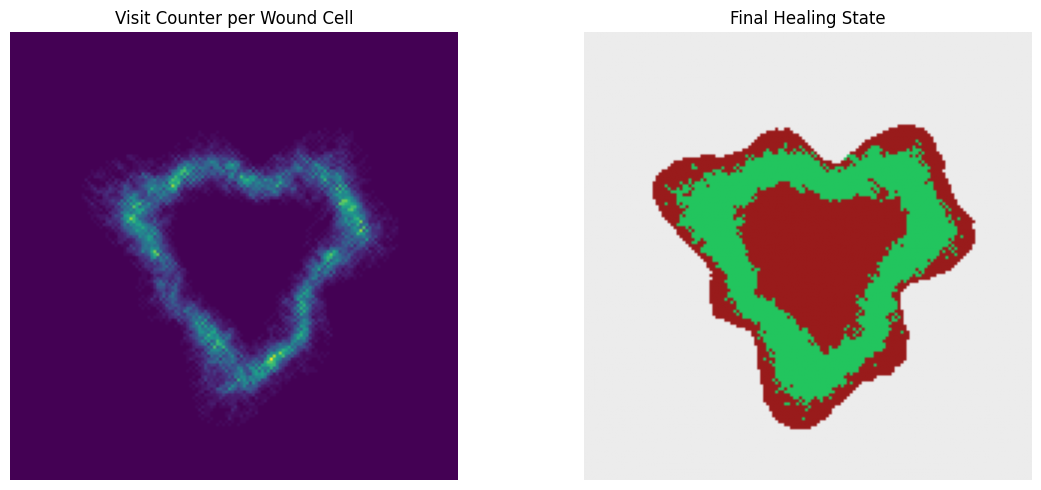

In [239]:
# Display a final summary view
final_state = np.zeros(wound_mask.shape, dtype=np.uint8)
final_state[wound_mask] = 1
final_state[healed] = 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(visit_counts, origin="lower", cmap="viridis")
axes[0].set_title("Visit Counter per Wound Cell")
axes[0].axis("off")

axes[1].imshow(final_state, origin="lower", cmap=ListedColormap(["#ececec", "#991b1b", "#22c55e"]))
axes[1].set_title("Final Healing State")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Section 2: No Drift — Boundary-Blocked Random Walk

In this variant walkers perform a **pure random walk** with no directional bias toward (or away from) the wound centre.
Walkers are still **blocked from leaving the wound**: any candidate step that would land outside the wound mask is rejected.
This serves as a null-model baseline to contrast with the drift-driven healing above.


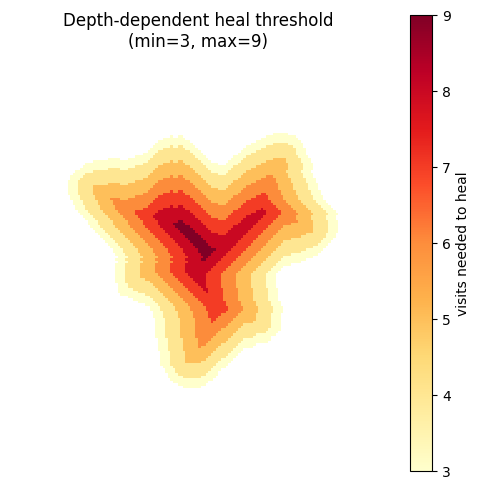

[No-drift] Saved snapshots : 68
[No-drift] Healed cells    : 3224 / 6547 (49.2%)
Threshold range            : 3 – 9 visits


In [240]:
def run_nodrift_healing(mask, start_cells_rc, dist_to_boundary,
                        n_steps, min_threshold, max_threshold, snapshot_every):
    """Pure random walk, boundary-blocked.
    Heal threshold scales linearly with BFS distance from boundary:
      boundary cells  → min_threshold visits needed
      deepest cells   → max_threshold visits needed
    """
    walkers = start_cells_rc.copy().astype(int)
    visit_counts_nd = np.zeros(mask.shape, dtype=np.int32)
    healed_nd = np.zeros(mask.shape, dtype=bool)

    # Pre-compute per-cell threshold map
    max_dist = dist_to_boundary[np.isfinite(dist_to_boundary)].max()
    threshold_map = np.where(
        mask,
        np.round(
            min_threshold + (max_threshold - min_threshold)
            * np.clip(dist_to_boundary, 0, max_dist) / (max_dist + 1e-9)
        ).astype(np.int32),
        0,
    )

    snapshots_nd = []
    offsets = np.array([
        [-1, -1], [-1, 0], [-1, 1],
        [0, -1],            [0, 1],
        [1, -1],  [1, 0],  [1, 1],
    ], dtype=int)

    for step in range(n_steps):
        for i in range(len(walkers)):
            candidates = walkers[i][None, :] + offsets
            valid = (
                (candidates[:, 0] >= 0) & (candidates[:, 0] < mask.shape[0])
                & (candidates[:, 1] >= 0) & (candidates[:, 1] < mask.shape[1])
            )
            candidates = candidates[valid]
            in_wound = mask[candidates[:, 0], candidates[:, 1]]
            candidates = candidates[in_wound]

            if len(candidates) == 0:
                continue

            explore_score = 1.0 / (1.0 + visit_counts_nd[candidates[:, 0], candidates[:, 1]])
            jitter = rng.random(size=len(candidates))
            score = 0.5 * explore_score + 0.5 * jitter
            walkers[i] = candidates[int(np.argmax(score))]

            rr, cc = walkers[i]
            visit_counts_nd[rr, cc] += 1
            if visit_counts_nd[rr, cc] >= threshold_map[rr, cc]:
                healed_nd[rr, cc] = True

        if (step % snapshot_every == 0) or (step == n_steps - 1):
            snapshots_nd.append((step, visit_counts_nd.copy(), healed_nd.copy(), walkers.copy()))

    return snapshots_nd, visit_counts_nd, healed_nd, threshold_map


# ── Visualise threshold map before running ───────────────────────────────────
max_dist_tmp = dist_to_boundary[np.isfinite(dist_to_boundary)].max()
threshold_map_preview = np.where(
    wound_mask,
    np.round(
        heal_threshold + (heal_threshold * 3 - heal_threshold)
        * np.clip(dist_to_boundary, 0, max_dist_tmp) / (max_dist_tmp + 1e-9)
    ).astype(np.int32),
    0,
)
thresh_plot = threshold_map_preview.astype(float)
thresh_plot[~wound_mask] = np.nan

fig_th, ax_th = plt.subplots(figsize=(5, 5))
im_th = ax_th.imshow(thresh_plot, origin="lower", cmap="YlOrRd", interpolation="nearest")
plt.colorbar(im_th, ax=ax_th, label="visits needed to heal")
ax_th.set_title(f"Depth-dependent heal threshold\n(min={heal_threshold}, max={heal_threshold * 3})")
ax_th.axis("off")
plt.tight_layout(); plt.show()

snapshots_nd, visit_counts_nd, healed_nd, threshold_map_nd = run_nodrift_healing(
    mask=wound_mask,
    start_cells_rc=start_cells_rc,
    dist_to_boundary=dist_to_boundary,
    n_steps=num_steps,
    min_threshold=heal_threshold,
    max_threshold=heal_threshold * 3,
    snapshot_every=snapshot_every,
)

print(f"[No-drift] Saved snapshots : {len(snapshots_nd)}")
print(f"[No-drift] Healed cells    : {healed_nd.sum()} / {wound_mask.sum()} "
      f"({100 * healed_nd.sum() / wound_mask.sum():.1f}%)")
print(f"Threshold range            : {threshold_map_nd[wound_mask].min()} – {threshold_map_nd[wound_mask].max()} visits")


In [241]:
output_gif_nd = "wound_healing_nodrift.gif"

fig_nd, ax_nd = plt.subplots(figsize=(7, 7))

init_state_nd = make_state(wound_mask, snapshots_nd[0][2])
img_nd = ax_nd.imshow(init_state_nd, cmap=cmap, vmin=0, vmax=2, origin="lower", animated=True)
walker_scatter_nd = ax_nd.scatter(
    snapshots_nd[0][3][:, 1], snapshots_nd[0][3][:, 0],
    c="#f472b6", s=16, alpha=0.9, animated=True
)
ax_nd.set_title("Wound Healing — No Drift, Boundary-Blocked (Step 0)")
ax_nd.set_xlim(0, grid_size - 1)
ax_nd.set_ylim(0, grid_size - 1)
ax_nd.set_aspect("equal")
ax_nd.axis("off")

def update_nd(frame_idx):
    step, _, healed_frame, walkers_frame = snapshots_nd[frame_idx]
    img_nd.set_data(make_state(wound_mask, healed_frame))
    walker_scatter_nd.set_offsets(np.column_stack([walkers_frame[:, 1], walkers_frame[:, 0]]))
    healed_pct = 100 * healed_frame.sum() / wound_mask.sum()
    ax_nd.set_title(f"No-Drift Healing | Step {step} | Healed {healed_pct:.1f}%")
    return img_nd, walker_scatter_nd

anim_nd = FuncAnimation(fig_nd, update_nd, frames=len(snapshots_nd), interval=70, blit=True)
anim_nd.save(output_gif_nd, writer=PillowWriter(fps=14))
plt.close(fig_nd)

print(f"GIF saved to: {output_gif_nd}")


GIF saved to: wound_healing_nodrift.gif


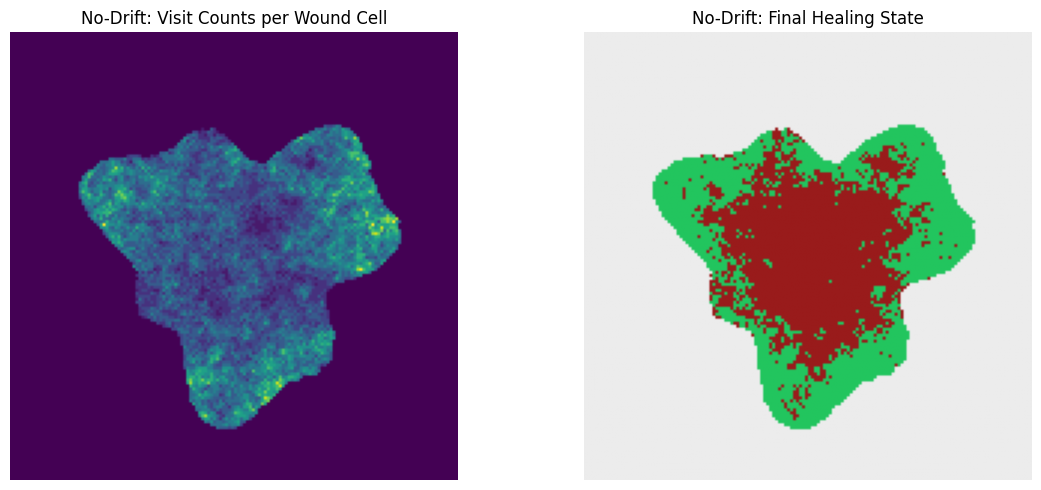

In [242]:
# Final summary — no-drift run
final_state_nd = np.zeros(wound_mask.shape, dtype=np.uint8)
final_state_nd[wound_mask] = 1
final_state_nd[healed_nd] = 2

fig_s, axes_s = plt.subplots(1, 2, figsize=(12, 5))
axes_s[0].imshow(visit_counts_nd, origin="lower", cmap="viridis")
axes_s[0].set_title("No-Drift: Visit Counts per Wound Cell")
axes_s[0].axis("off")

axes_s[1].imshow(final_state_nd, origin="lower", cmap=ListedColormap(["#ececec", "#991b1b", "#22c55e"]))
axes_s[1].set_title("No-Drift: Final Healing State")
axes_s[1].axis("off")

plt.tight_layout()
plt.show()
